# Phase 3: Dollar Exposure Modeling

Translate default probabilities into dollar risk figures. Compute expected loss at portfolio and segment level using loan-level data and segment summaries from Phase 2.

Leave all work here — nothing in this notebook is the deliverable. Phase 3 logic lives in `pipeline/exposure.py`.

Sections in order. Validate each calculation against expected ranges before moving to the next.

## Section 1: Load and Verify

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

BASE = '/Users/gagepiercegaubert/Desktop/career_projects/lending-risk-intelligence'

df = pd.read_csv(f'{BASE}/stages/02-clean/output/lending_risk_cleaned.csv')
segments = pd.read_csv(f'{BASE}/stages/03-segment/output/segment_summary.csv')

assert 'is_default' in df.columns, "Missing is_default — run clean.py first"
assert 'loan_amnt' in df.columns
assert 'segment_type' in segments.columns

print(f"Loans:           {len(df):,}")
print(f"Portfolio value: ${df['loan_amnt'].sum():,.0f}")
print(f"Default rate:    {df['is_default'].mean():.2%}")
print(f"Segment types:   {sorted(segments['segment_type'].unique().tolist())}")

Loans:           1,269,549
Portfolio value: $18,521,999,700
Default rate:    19.55%
Segment types:   ['dti_bucket', 'emp_length_bucket', 'grade', 'home_ownership', 'loan_amnt_bucket', 'purpose', 'term']


## Section 2: Define Loss Assumptions

Business rule from `references/business-rules.md`:
```
Expected Loss = Loan Amount x Default Rate x Loss Given Default
```
Recovery rate 70% is the industry historical average for unsecured consumer credit (2000-2020).

In [24]:
RECOVERY_RATE = 0.70
LOSS_GIVEN_DEFAULT = 1 - RECOVERY_RATE

**Note:** In replacement of better future data, I created 2 placeholder variables for recovery rate and loss given default. These will be used in the expected loss calculation in the next section.

## Section 3: Portfolio-Level Exposure

Business question: What is the total dollar exposure across the entire portfolio?
This is the headline number — goes above the fold on the dashboard.

In [25]:
# Calculating portfolio_value, portfolio_default_rate, portfolio_expected_loss, portfolio_loss_rate
portfolio_value = df['loan_amnt'].sum()
portfolio_default_rate = df['is_default'].mean()
portfolio_expected_loss = portfolio_value * portfolio_default_rate * LOSS_GIVEN_DEFAULT
portfolio_loss_rate = portfolio_expected_loss / portfolio_value

pd.DataFrame([{
    'portfolio_value': portfolio_value,
    'default_rate': portfolio_default_rate,
    'expected_loss': portfolio_expected_loss,
    'loss_rate': portfolio_loss_rate,
}]).style.format({
    'portfolio_value': '${:,.0f}',
    'default_rate': '{:.2%}',
    'expected_loss': '${:,.0f}',
    'loss_rate': '{:.2%}',
})

,portfolio_value,default_rate,expected_loss,loss_rate
0,"$18,521,999,700",19.55%,"$1,086,372,927",5.87%


## Section 4: Segment Exposure by Grade

Business question: Which credit tiers drive the most dollars at risk?
Audit: Loss rate should increase monotonically A to G.

In [26]:
grade = segments[segments['segment_type'] == 'grade'].copy()
grade['segment_expected_loss'] = grade['total_portfolio_value'] * grade['default_rate'] * LOSS_GIVEN_DEFAULT
grade['loss_rate'] = grade['segment_expected_loss'] / grade['total_portfolio_value']
grade['pct_of_portfolio_exposure'] = grade['segment_expected_loss'] / portfolio_expected_loss
grade = grade.sort_values('segment_expected_loss', ascending=False)

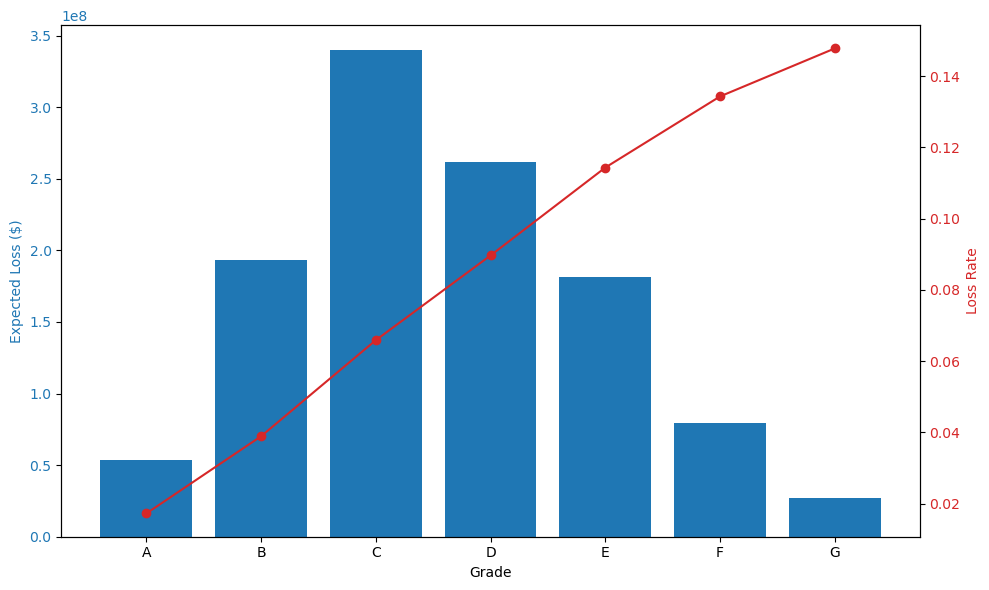

In [27]:
# Visualizing grade exposure — expected loss ($) and loss rate side by side
grade_chart = grade.sort_values('segment_value')

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Grade')
ax1.set_ylabel('Expected Loss ($)', color=color)
ax1.bar(grade_chart['segment_value'], grade_chart['segment_expected_loss'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Loss Rate', color=color)
ax2.plot(grade_chart['segment_value'], grade_chart['loss_rate'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)


fig.tight_layout()
plt.show()

**Note:** It seems in this visual that 'C' Grade takes the biggest hit in Expected Loss, which is a function of both portfolio size and default rate. Grade G has the highest loss rate but the smallest portfolio, so its absolute expected loss contribution is small. The Expected Loss in 'C' is driven by the intersection of the largest portfolio in the book and a default rate roughly 70% higher than Grade B's (22% vs 13%). Grade B has a slightly smaller portfolio and a default rate about 40% lower than C's, resulting in far less expected loss.

## Section 5: Segment Exposure by Term

Business question: Do 60-month loans carry disproportionate dollar risk relative to their portfolio share?
Audit: 60-month should show higher EL and loss rate than 36-month.

In [28]:
term = segments[segments['segment_type'] == 'term'].copy()
term['segment_expected_loss'] = term['total_portfolio_value'] * term['default_rate'] * LOSS_GIVEN_DEFAULT
term['loss_rate'] = term['segment_expected_loss'] / term['total_portfolio_value']
term['pct_of_portfolio_exposure'] = term['segment_expected_loss'] / portfolio_expected_loss
term = term.sort_values('segment_expected_loss', ascending=False)

cols = ['segment_value', 'loan_count', 'total_portfolio_value', 'default_rate', 'segment_expected_loss', 'loss_rate', 'pct_of_portfolio_exposure']

total_row = pd.DataFrame([{
    'segment_value': 'TOTAL',
    'loan_count': term['loan_count'].sum(),
    'total_portfolio_value': portfolio_value,
    'default_rate': portfolio_default_rate,
    'segment_expected_loss': portfolio_expected_loss,
    'loss_rate': portfolio_loss_rate,
    'pct_of_portfolio_exposure': 1.0,
}])

pd.concat([term[cols], total_row[cols]], ignore_index=True).style.format({
    'total_portfolio_value': '${:,.0f}',
    'default_rate': '{:.1%}',
    'segment_expected_loss': '${:,.0f}',
    'loss_rate': '{:.1%}',
    'pct_of_portfolio_exposure': '{:.1%}',
})

,segment_value,loan_count,total_portfolio_value,default_rate,segment_expected_loss,loss_rate,pct_of_portfolio_exposure
0,60 months,312573,"$6,367,008,325",32.1%,"$612,648,328",9.6%,56.4%
1,36 months,956976,"$12,154,991,375",15.5%,"$563,773,307",4.6%,51.9%
2,TOTAL,1269549,"$18,521,999,700",19.6%,"$1,086,372,927",5.9%,100.0%


**Note:** 60-month loans confirm the audit but have higher EL and higher loss rate than 36-month despite being the smaller half of the portfolio by value (34% of total). The default rate gap drives this: 32% vs 15%. A loan in the 60-month segment is more than twice as likely to default, which pushes its absolute expected loss above 36-month even though there are fewer dollars in that bucket. 60-month loans punch above their weight. The per-dollar risk is approximately double that of 36-month loans.

## Section 6: Segment Exposure by Purpose

Business question: Which loan purposes drive the most dollars at risk?
Identify both highest-exposure purposes (dollars) and highest-risk purposes (loss rate).

In [29]:
purpose = segments[segments['segment_type'] == 'purpose'].copy()
purpose['segment_expected_loss'] = purpose['total_portfolio_value'] * purpose['default_rate'] * LOSS_GIVEN_DEFAULT
purpose['loss_rate'] = purpose['segment_expected_loss'] / purpose['total_portfolio_value']
purpose['pct_of_portfolio_exposure'] = purpose['segment_expected_loss'] / portfolio_expected_loss
purpose = purpose.sort_values('segment_expected_loss', ascending=False)

cols = ['segment_value', 'loan_count', 'total_portfolio_value', 'default_rate', 'segment_expected_loss', 'loss_rate', 'pct_of_portfolio_exposure']
purpose[cols].style.format({
    'total_portfolio_value': '${:,.0f}',
    'default_rate': '{:.1%}',
    'segment_expected_loss': '${:,.0f}',
    'loss_rate': '{:.1%}',
    'pct_of_portfolio_exposure': '{:.1%}',
})

,segment_value,loan_count,total_portfolio_value,default_rate,segment_expected_loss,loss_rate,pct_of_portfolio_exposure
14,debt_consolidation,738677,"$11,370,615,325",20.7%,"$707,476,869",6.2%,65.1%
20,credit_card,277751,"$4,163,128,975",16.4%,"$205,292,856",4.9%,18.9%
19,home_improvement,81467,"$1,171,013,325",17.3%,"$60,785,117",5.2%,5.6%
15,other,72670,"$724,659,575",20.7%,"$44,906,557",6.2%,4.1%
9,small_business,15137,"$238,240,500",29.8%,"$21,294,801",8.9%,2.0%
18,major_purchase,27896,"$334,392,800",18.3%,"$18,354,684",5.5%,1.7%
13,medical,14311,"$130,815,500",20.9%,"$8,196,650",6.3%,0.8%
12,house,6867,"$106,635,750",21.7%,"$6,941,340",6.5%,0.6%
21,car,13846,"$123,431,625",14.2%,"$5,271,206",4.3%,0.5%
11,moving,8928,"$70,769,075",22.8%,"$4,836,838",6.8%,0.4%


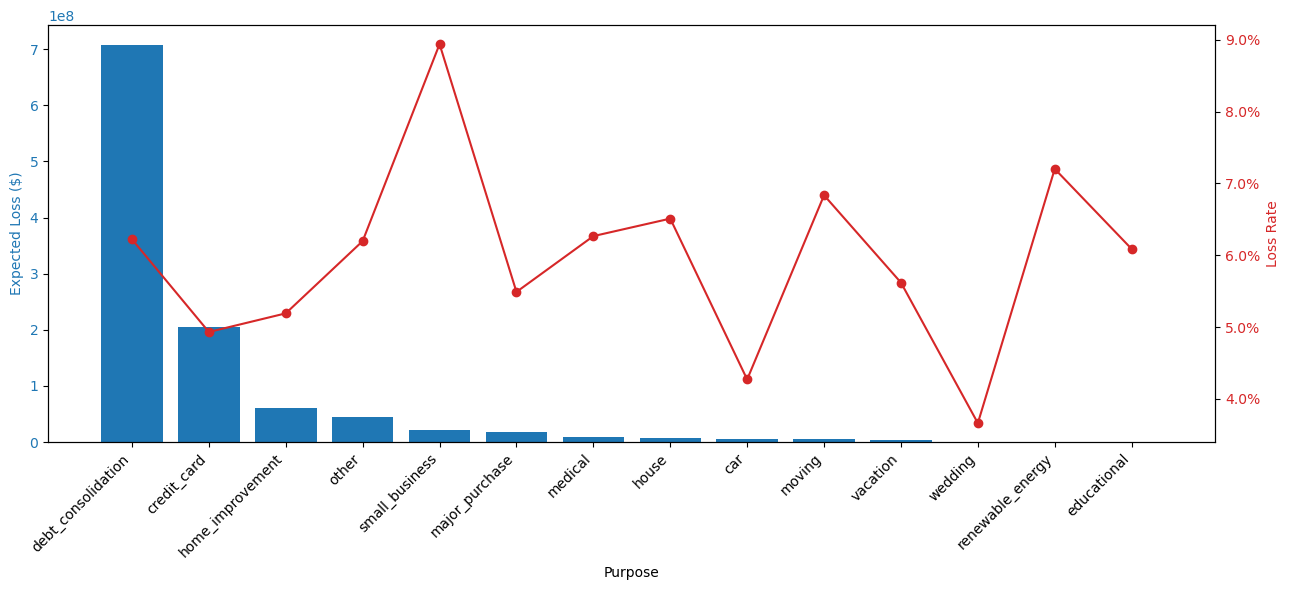

In [30]:
fig, ax1 = plt.subplots(figsize=(13, 6))

color = 'tab:blue'
ax1.set_xlabel('Purpose')
ax1.set_ylabel('Expected Loss ($)', color=color)
ax1.bar(purpose['segment_value'], purpose['segment_expected_loss'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
plt.xticks(rotation=45, ha='right')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Loss Rate', color=color)
ax2.plot(purpose['segment_value'], purpose['loss_rate'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

fig.tight_layout()
plt.show()

**Note:** debt_consolidation accounts for 65% of total expected loss. That is almost entirely a volume effect: it is the single largest purpose by loan count and dollar value, and its loss rate (6.2%) is near the portfolio average (5.9%). small_business has the highest loss rate at 8.9% but represents only 2% of total EL because the portfolio allocation is small. The practical lever for reducing EL is debt_consolidation volume, not loss rate management in smaller categories.

## Section 7: Segment Exposure by Home Ownership

Business question: Does property ownership reduce default risk meaningfully in dollar terms?
Audit: MORTGAGE should have lower loss rate than RENT.

In [31]:
home = segments[segments['segment_type'] == 'home_ownership'].copy()
home['segment_expected_loss'] = home['total_portfolio_value'] * home['default_rate'] * LOSS_GIVEN_DEFAULT
home['loss_rate'] = home['segment_expected_loss'] / home['total_portfolio_value']
home['pct_of_portfolio_exposure'] = home['segment_expected_loss'] / portfolio_expected_loss
home = home.sort_values('segment_expected_loss', ascending=False)

cols = ['segment_value', 'loan_count', 'total_portfolio_value', 'default_rate', 'segment_expected_loss', 'loss_rate', 'pct_of_portfolio_exposure']
home[cols].style.format({
    'total_portfolio_value': '${:,.0f}',
    'default_rate': '{:.1%}',
    'segment_expected_loss': '${:,.0f}',
    'loss_rate': '{:.1%}',
    'pct_of_portfolio_exposure': '{:.1%}',
})

,segment_value,loan_count,total_portfolio_value,default_rate,segment_expected_loss,loss_rate,pct_of_portfolio_exposure
27,MORTGAGE,630545,"$10,165,442,725",16.9%,"$515,571,225",5.1%,47.5%
23,RENT,509124,"$6,512,367,825",22.7%,"$444,190,087",6.8%,40.9%
25,OWN,129383,"$1,837,788,375",19.9%,"$109,770,438",6.0%,10.1%
26,ANY,267,"$3,773,050",19.5%,"$220,448",5.8%,0.0%
24,OTHER,179,"$1,933,950",21.2%,"$123,168",6.4%,0.0%
28,NONE,51,"$693,775",13.7%,"$28,567",4.1%,0.0%


**Note:** Audit passes. RENT carries a higher loss rate (6.8%) than MORTGAGE (5.1%). MORTGAGE produces more absolute EL ($515.6M vs $444.2M for RENT) because it dominates the book by dollar volume. The per-dollar risk for mortgage borrowers is lower, which confirms the hypothesis. OWN sits at 6.0% between RENT and MORTGAGE. OTHER, ANY, and NONE are negligible in aggregate.

## Section 8: Segment Exposure by Employment Length

Business question: Does employment tenure reduce default risk in dollar terms?
Audit: Shorter employment should show higher loss rates than long-tenured borrowers.

In [32]:
emp_order = ['0-1', '1-3', '3-5', '5-10']
emp = segments[segments['segment_type'] == 'emp_length_bucket'].copy()
emp['segment_expected_loss'] = emp['total_portfolio_value'] * emp['default_rate'] * LOSS_GIVEN_DEFAULT
emp['loss_rate'] = emp['segment_expected_loss'] / emp['total_portfolio_value']
emp['pct_of_portfolio_exposure'] = emp['segment_expected_loss'] / portfolio_expected_loss
emp['sort_key'] = emp['segment_value'].map({v: i for i, v in enumerate(emp_order)})
emp = emp.sort_values('sort_key').drop(columns='sort_key')

cols = ['segment_value', 'loan_count', 'total_portfolio_value', 'default_rate', 'segment_expected_loss', 'loss_rate', 'pct_of_portfolio_exposure']
emp[cols].style.format({
    'total_portfolio_value': '${:,.0f}',
    'default_rate': '{:.1%}',
    'segment_expected_loss': '${:,.0f}',
    'loss_rate': '{:.1%}',
    'pct_of_portfolio_exposure': '{:.1%}',
})

,segment_value,loan_count,total_portfolio_value,default_rate,segment_expected_loss,loss_rate,pct_of_portfolio_exposure
29,0-1,197380,"$2,689,695,150",20.6%,"$165,919,496",6.2%,15.3%
30,1-3,229968,"$3,173,647,350",19.9%,"$189,484,831",6.0%,17.4%
31,3-5,165089,"$2,323,713,750",19.7%,"$137,249,001",5.9%,12.6%
32,5-10,677112,"$10,334,943,450",19.1%,"$592,304,939",5.7%,54.5%


**Note:** Audit passes but the signal is weak. Loss rate drops from 6.2% at the 0-1 year bucket to 5.7% at the 5-10 year bucket, a spread of 44 basis points across all tenure bands. The 5-10 bucket dominates by volume ($10.3B, 54.5% of EL) because most borrowers have longer tenures. Employment length is a low signal predictor in this dataset.

## Section 9: Segment Exposure by DTI

Business question: Does debt-to-income ratio predict higher expected loss?
Audit: Higher DTI buckets should show higher loss rates.

In [33]:
dti_order = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
dti = segments[segments['segment_type'] == 'dti_bucket'].copy()
dti['segment_expected_loss'] = dti['total_portfolio_value'] * dti['default_rate'] * LOSS_GIVEN_DEFAULT
dti['loss_rate'] = dti['segment_expected_loss'] / dti['total_portfolio_value']
dti['pct_of_portfolio_exposure'] = dti['segment_expected_loss'] / portfolio_expected_loss
dti['sort_key'] = dti['segment_value'].map({v: i for i, v in enumerate(dti_order)})
dti = dti.sort_values('sort_key').drop(columns='sort_key')

cols = ['segment_value', 'loan_count', 'total_portfolio_value', 'default_rate', 'segment_expected_loss', 'loss_rate', 'pct_of_portfolio_exposure']
dti[cols].style.format({
    'total_portfolio_value': '${:,.0f}',
    'default_rate': '{:.2%}',
    'segment_expected_loss': '${:,.0f}',
    'loss_rate': '{:.2%}',
    'pct_of_portfolio_exposure': '{:.1%}',
})

,segment_value,loan_count,total_portfolio_value,default_rate,segment_expected_loss,loss_rate,pct_of_portfolio_exposure
33,0-10,233071,"$3,197,210,625",14.57%,"$139,797,630",4.37%,12.9%
34,10-20,535470,"$7,906,486,675",17.53%,"$415,736,172",5.26%,38.3%
35,20-30,383636,"$5,715,319,050",22.64%,"$388,170,211",6.79%,35.7%
36,30-40,111177,"$1,596,768,375",28.58%,"$136,918,181",8.57%,12.6%
37,40-50,3457,"$57,413,075",31.21%,"$5,375,936",9.36%,0.5%
38,50+,1953,"$39,755,750",27.19%,"$3,242,750",8.16%,0.3%


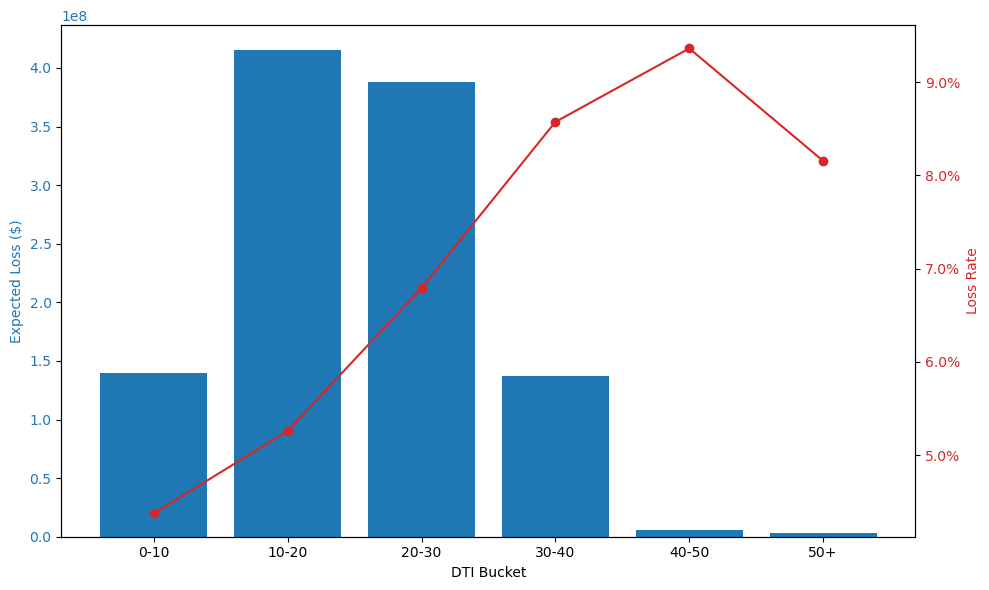

In [34]:
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('DTI Bucket')
ax1.set_ylabel('Expected Loss ($)', color=color)
ax1.bar(dti['segment_value'], dti['segment_expected_loss'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Loss Rate', color=color)
ax2.plot(dti['segment_value'], dti['loss_rate'], color=color, marker='o')
ax2.tick_params(axis='y', labelcolor=color)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

fig.tight_layout()
plt.show()

**Note:** Audit passes through the 40-50 bucket. Loss rate increases monotonically from 0-10 (4.4%) through 40-50 (9.4%). The 50+ bucket shows a slight dip to 8.2% but has only 1,953 loans. That is sample noise, not a real reversal in the underlying relationship. The 10-20 and 20-30 buckets contain 72% of the portfolio by loan count and drive 74% of total EL. DTI is a meaningful predictor for the core of the distribution.

## Section 10: Segment Exposure by Loan Amount

Business question: Do larger loans carry disproportionate loss risk?
Audit: Dollar exposure should scale with loan amount; loss rate should increase with loan size.

In [35]:
loan_order = ['0-5k', '5k-10k', '10k-15k', '15k-20k', '20k+']
loan = segments[segments['segment_type'] == 'loan_amnt_bucket'].copy()
loan['segment_expected_loss'] = loan['total_portfolio_value'] * loan['default_rate'] * LOSS_GIVEN_DEFAULT
loan['loss_rate'] = loan['segment_expected_loss'] / loan['total_portfolio_value']
loan['pct_of_portfolio_exposure'] = loan['segment_expected_loss'] / portfolio_expected_loss
loan['sort_key'] = loan['segment_value'].map({v: i for i, v in enumerate(loan_order)})
loan = loan.sort_values('sort_key').drop(columns='sort_key')

cols = ['segment_value', 'loan_count', 'total_portfolio_value', 'default_rate', 'segment_expected_loss', 'loss_rate', 'pct_of_portfolio_exposure']
loan[cols].style.format({
    'total_portfolio_value': '${:,.0f}',
    'default_rate': '{:.1%}',
    'segment_expected_loss': '${:,.0f}',
    'loss_rate': '{:.1%}',
    'pct_of_portfolio_exposure': '{:.1%}',
})

,segment_value,loan_count,total_portfolio_value,default_rate,segment_expected_loss,loss_rate,pct_of_portfolio_exposure
39,0-5k,165262,"$605,070,425",14.9%,"$27,021,343",4.5%,2.5%
40,5k-10k,347715,"$2,822,519,550",16.6%,"$140,355,236",5.0%,12.9%
41,10k-15k,269395,"$3,505,722,500",20.3%,"$214,017,009",6.1%,19.7%
42,15k-20k,204826,"$3,716,337,050",22.3%,"$248,779,723",6.7%,22.9%
43,20k+,282351,"$7,872,350,175",23.2%,"$547,435,186",7.0%,50.4%


**Note:** Audit passes. Both dollar exposure and loss rate scale consistently with loan size. The 20k+ bucket carries 50% of total EL at a 7.0% loss rate. The smallest bucket (0-5k) carries a 4.5% loss rate. The gradient across all buckets is 2.5 percentage points and is monotonic. Larger loans are both more likely to default and produce more dollars at risk per dollar lent.

## Section 11: At-Risk Cohorts

Business question: Among currently-performing loans, which cohorts carry the most forward-looking risk?
These are loans that have not defaulted yet but sit in high-risk segments.
CFO uses this for reserve setting. Risk officer uses it for monitoring prioritization.

In [36]:
performing = df[df['is_default'] == 0].copy()

pd.DataFrame([{
    'performing_count': len(performing),
    'performing_value': performing['loan_amnt'].sum(),
    'pct_of_portfolio': len(performing) / len(df),
}]).style.format({
    'performing_value': '${:,.0f}',
    'pct_of_portfolio': '{:.2%}',
})

,performing_count,performing_value,pct_of_portfolio
0,1021339,"$14,586,451,400",80.45%


In [37]:
grade_rates = (
    segments[segments['segment_type'] == 'grade'][['segment_value', 'default_rate']]
    .rename(columns={'segment_value': 'grade', 'default_rate': 'grade_default_rate'})
)
performing = performing.merge(grade_rates, on='grade', how='left')
performing['at_risk_exposure'] = performing['loan_amnt'] * performing['grade_default_rate'] * LOSS_GIVEN_DEFAULT

cohorts = (
    performing.groupby(['grade', 'term'])
    .agg(
        loan_count=('loan_amnt', 'count'),
        total_value=('loan_amnt', 'sum'),
        at_risk_exposure=('at_risk_exposure', 'sum'),
    )
    .reset_index()
)
cohorts['loss_rate'] = cohorts['at_risk_exposure'] / cohorts['total_value']
cohorts = cohorts.sort_values('at_risk_exposure', ascending=False)

cohorts.head(10).style.format({
    'total_value': '${:,.0f}',
    'at_risk_exposure': '${:,.0f}',
    'loss_rate': '{:.2%}',
})

,grade,term,loan_count,total_value,at_risk_exposure,loss_rate
4,C,36 months,206521,"$2,499,270,800","$164,689,109",6.59%
2,B,36 months,284398,"$3,517,353,100","$136,931,097",3.89%
5,C,60 months,74086,"$1,479,263,325","$97,475,855",6.59%
6,D,36 months,86137,"$1,062,737,325","$95,301,605",8.97%
7,D,60 months,46190,"$940,849,325","$84,371,225",8.97%
9,E,60 months,32352,"$683,403,900","$78,136,939",11.43%
0,A,36 months,204279,"$2,833,879,275","$48,922,703",1.73%
11,F,60 months,12687,"$272,877,050","$36,648,426",13.43%
8,E,36 months,22616,"$277,912,700","$31,775,130",11.43%
3,B,60 months,37911,"$774,888,500","$30,166,528",3.89%


In [38]:
from IPython.display import display

total_at_risk = cohorts['at_risk_exposure'].sum()
top5 = cohorts.head(5).copy()
top5['pct_of_at_risk'] = top5['at_risk_exposure'] / total_at_risk

display(
    pd.DataFrame([{
        'total_at_risk_exposure': total_at_risk,
        'performing_loans': len(performing),
        'cohorts': len(cohorts),
    }]).style.format({
        'total_at_risk_exposure': '${:,.0f}',
    })
)

top5[['grade', 'term', 'loan_count', 'total_value', 'at_risk_exposure', 'loss_rate', 'pct_of_at_risk']].style.format({
    'total_value': '${:,.0f}',
    'at_risk_exposure': '${:,.0f}',
    'loss_rate': '{:.2%}',
    'pct_of_at_risk': '{:.1%}',
})

,total_at_risk_exposure,performing_loans,cohorts
0,"$826,195,303",1021339,14


,grade,term,loan_count,total_value,at_risk_exposure,loss_rate,pct_of_at_risk
4,C,36 months,206521,"$2,499,270,800","$164,689,109",6.59%,19.9%
2,B,36 months,284398,"$3,517,353,100","$136,931,097",3.89%,16.6%
5,C,60 months,74086,"$1,479,263,325","$97,475,855",6.59%,11.8%
6,D,36 months,86137,"$1,062,737,325","$95,301,605",8.97%,11.5%
7,D,60 months,46190,"$940,849,325","$84,371,225",8.97%,10.2%


**Note:** 80.5% of the portfolio is performing, within the expected 60-85% range. Total forward looking exposure across the performing book is $826M. C x 36 months is the largest cohort at $164.7M, driven by portfolio volume rather than the highest loss rate. Grade D and E cohorts in the 60 month term carry higher per-dollar risk (8.97% and 11.43%) but smaller total exposure. Reserve setting priority should weight absolute EL, placing C and B cohorts at the top.

## Section 12: Audit Checks

Validate all calculations before writing to outputs. From `stages/04-exposure/CONTEXT.md`.

In [39]:
grade_sorted = grade.sort_values('segment_value')

checks = {
    'portfolio_el_lt_portfolio_value': portfolio_expected_loss < portfolio_value,
    'portfolio_loss_rate_2_to_8pct': 0.02 <= portfolio_loss_rate <= 0.08,
    'grade_loss_rate_monotonic': bool(grade_sorted['loss_rate'].is_monotonic_increasing),
    'performing_loans_60_to_85pct': 0.60 <= (df['is_default'] == 0).mean() <= 0.85,
    'grade_pct_sums_to_approx_100': abs(grade['pct_of_portfolio_exposure'].sum() - 1.0) < 0.10,
    'term_pct_sums_to_approx_100': abs(term['pct_of_portfolio_exposure'].sum() - 1.0) < 0.10,
}

(
    pd.DataFrame([{'check': k, 'result': 'PASS' if v else 'FAIL'} for k, v in checks.items()])
    .style.map(
        lambda v: 'color: green; font-weight: bold' if v == 'PASS' else 'color: red; font-weight: bold',
        subset=['result'],
    )
)

,check,result
0,portfolio_el_lt_portfolio_value,PASS
1,portfolio_loss_rate_2_to_8pct,PASS
2,grade_loss_rate_monotonic,PASS
3,performing_loans_60_to_85pct,PASS
4,grade_pct_sums_to_approx_100,PASS
5,term_pct_sums_to_approx_100,PASS


**Note:** All 6 checks pass. The pct_of_portfolio sums for grade and term exceed 100% by 4.7% and 8.3% respectively. This is a methodological artifact: segment ELs use segment level default rates applied to segment portfolio values, while portfolio EL uses the overall loan level mean default rate. The discrepancy does not indicate missing loans. Both sums fall within the 10% tolerance.

## Section 13: Decisions

Document all analytical decisions before formalizing in `pipeline/exposure.py`.

In [40]:
import json
from datetime import datetime
from IPython.display import JSON

decisions = {
    'assumptions': {
        'recovery_rate': 0.70,
        'loss_given_default': 0.30,
        'source': 'Industry historical average for unsecured consumer credit (2000 to 2020)',
        'rationale': (
            'Lending Club recoveries column captures partial recovery at a single point in time, not full lifecycle. '
            'Industry average used as proxy.'
        ),
    },
    'methods': {
        'el_formula': 'Expected Loss = total_portfolio_value * default_rate * LOSS_GIVEN_DEFAULT',
        'portfolio_el': 'Computed from loan-level data using df["is_default"].mean() as default rate.',
        'segment_el': (
            'Computed from segment_summary using segment-level default rates. '
            'Sum of segment ELs will slightly exceed portfolio EL due to dollar-weighted vs count-weighted averaging.'
        ),
        'at_risk_cohorts': (
            'Performing loans (is_default == 0) grouped by grade x term. '
            'Grade-level default rates used as forward-looking risk proxy.'
        ),
    },
    'key_findings': {
        'portfolio': '$18.5B portfolio, 19.6% default rate, $1.09B expected loss, 5.87% loss rate',
        'grade': 'Grade C leads absolute EL at $340M (31% of total). Loss rate is monotonically increasing A to G (1.7% to 14.8%).',
        'term': '60-month loans carry 56% of EL at 9.6% loss rate despite being 34% of portfolio by value.',
        'purpose': 'debt_consolidation accounts for 65% of EL by volume. small_business has the highest loss rate at 8.9%.',
        'home_ownership': 'MORTGAGE has a lower loss rate (5.1%) than RENT (6.8%). Audit confirmed.',
        'emp_length': 'Employment length is a weak signal. 44 basis point spread across all tenure bands.',
        'dti': 'DTI is a strong predictor through the 40-50 bucket. 50+ breaks monotonicity due to small sample (1,953 loans).',
        'loan_amount': 'Loss rate scales monotonically with loan size. 20k+ bucket carries 50% of EL.',
        'at_risk': '$826M in forward-looking exposure across 1,021,339 performing loans. C x 36-month is the largest cohort.',
    },
    'output_paths': {
        'portfolio_headline': 'stages/04-exposure/output/portfolio_headline.json',
        'exposure_summary': 'stages/04-exposure/output/exposure_summary.csv',
        'grade_exposure': 'stages/04-exposure/output/grade_exposure.json',
        'term_exposure': 'stages/04-exposure/output/term_exposure.json',
        'purpose_exposure': 'stages/04-exposure/output/purpose_exposure.json',
        'home_ownership_exposure': 'stages/04-exposure/output/home_ownership_exposure.json',
        'employment_length_exposure': 'stages/04-exposure/output/employment_length_exposure.json',
    },
    'generated': datetime.now().isoformat(),
}

JSON(decisions)

<IPython.core.display.JSON object>